# Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Importing the data + printing

In [3]:
Data = pd.read_csv('DataSets/heart.csv',delimiter=',')
print(Data)

     age  sex  cp   trestbps  chol  ...   oldpeak   slope   ca   thal   target
0     63    1   3        145   233  ...       2.3       0    0      1        1
1     37    1   2        130   250  ...       3.5       0    0      2        1
2     41    0   1        130   204  ...       1.4       2    0      2        1
3     56    1   1        120   236  ...       0.8       2    0      2        1
4     57    0   0        120   354  ...       0.6       2    0      2        1
..   ...  ...  ..        ...   ...  ...       ...     ...  ...    ...      ...
298   57    0   0        140   241  ...       0.2       1    0      3        0
299   45    1   3        110   264  ...       1.2       1    0      3        0
300   68    1   0        144   193  ...       3.4       1    2      3        0
301   57    1   0        130   131  ...       1.2       1    1      3        0
302   57    0   1        130   236  ...       0.0       1    1      2        0

[303 rows x 14 columns]


# The models

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn . model_selection import train_test_split

X=Data.values[:,0:-1]
y=Data.values[:,-1]

X_train, X_test, y_train, y_test = train_test_split (X, y, test_size = 0.2 )

gini_model = DecisionTreeClassifier(criterion='gini', random_state=42)
gini_model.fit(X_train,y_train)

info_gain_model = DecisionTreeClassifier(criterion='entropy', random_state=42)
info_gain_model.fit(X_train,y_train)



DecisionTreeClassifier(criterion='entropy', random_state=42)

In [5]:
tree_ = gini_model.tree_
n_nodes = tree_.node_count
print(f"Number of nodes: {n_nodes}")
# Example: Iterating through nodes to get properties
for i in range(n_nodes):
    if tree_.children_left[i] != tree_.children_right[i]:  # Internal node
        print(f"Node {i}: Split on feature {tree_.feature[i]} <= {tree_.threshold[i]:.2f}")
    else:  # Leaf node
        print(f"Node {i}: Leaf node with impurity {tree_.impurity[i]:.2f}")
        

Number of nodes: 79
Node 0: Split on feature 2 <= 0.50
Node 1: Split on feature 11 <= 0.50
Node 2: Split on feature 12 <= 2.50
Node 3: Split on feature 7 <= 119.50
Node 4: Leaf node with impurity 0.00
Node 5: Split on feature 10 <= 0.50
Node 6: Leaf node with impurity 0.00
Node 7: Split on feature 0 <= 58.50
Node 8: Split on feature 4 <= 309.00
Node 9: Leaf node with impurity 0.00
Node 10: Split on feature 7 <= 144.00
Node 11: Leaf node with impurity 0.00
Node 12: Leaf node with impurity 0.00
Node 13: Split on feature 9 <= 0.60
Node 14: Split on feature 10 <= 1.50
Node 15: Leaf node with impurity 0.00
Node 16: Split on feature 4 <= 327.50
Node 17: Leaf node with impurity 0.00
Node 18: Leaf node with impurity 0.00
Node 19: Leaf node with impurity 0.00
Node 20: Split on feature 9 <= 0.65
Node 21: Split on feature 0 <= 50.50
Node 22: Split on feature 0 <= 42.00
Node 23: Leaf node with impurity 0.00
Node 24: Split on feature 6 <= 0.50
Node 25: Leaf node with impurity 0.00
Node 26: Leaf nod

In [6]:
tree_ = info_gain_model.tree_
n_nodes = tree_.node_count
print(f"Number of nodes: {n_nodes}")
# Example: Iterating through nodes to get properties
for i in range(n_nodes):
    if tree_.children_left[i] != tree_.children_right[i]:  # Internal node
        print(f"Node {i}: Split on feature {tree_.feature[i]} <= {tree_.threshold[i]:.2f}")
    else:  # Leaf node
        print(f"Node {i}: Leaf node with impurity {tree_.impurity[i]:.2f}")

Number of nodes: 71
Node 0: Split on feature 2 <= 0.50
Node 1: Split on feature 11 <= 0.50
Node 2: Split on feature 12 <= 2.50
Node 3: Split on feature 7 <= 146.00
Node 4: Split on feature 3 <= 116.00
Node 5: Leaf node with impurity 0.00
Node 6: Split on feature 6 <= 0.50
Node 7: Leaf node with impurity 0.00
Node 8: Leaf node with impurity 0.00
Node 9: Split on feature 4 <= 327.50
Node 10: Leaf node with impurity 0.00
Node 11: Split on feature 7 <= 166.00
Node 12: Leaf node with impurity 0.00
Node 13: Leaf node with impurity 0.00
Node 14: Split on feature 9 <= 0.65
Node 15: Split on feature 0 <= 50.50
Node 16: Split on feature 3 <= 117.00
Node 17: Split on feature 6 <= 0.50
Node 18: Leaf node with impurity 0.00
Node 19: Leaf node with impurity 0.00
Node 20: Leaf node with impurity 0.00
Node 21: Leaf node with impurity 0.00
Node 22: Leaf node with impurity 0.00
Node 23: Split on feature 0 <= 63.50
Node 24: Split on feature 4 <= 301.50
Node 25: Leaf node with impurity 0.00
Node 26: Split

# Comparing the models

In [7]:
print(" ---Gini index model :")
from sklearn . model_selection import cross_val_score
accuracies = cross_val_score ( estimator = gini_model , X = X_train , y = y_train , cv
=10 )
print ("Accuracy : {: .4f} %".format( accuracies . mean () *100 ))
print ("Standard Deviation : {:.4f} %".format( accuracies. std () *100 ))

print("\n ---Information Gain model :")
from sklearn . model_selection import cross_val_score
accuracies = cross_val_score ( estimator = info_gain_model , X = X_train , y = y_train , cv
=10 )
print ("Accuracy : {: .4f} %".format( accuracies . mean () *100 ))
print ("Standard Deviation : {:.4f} %".format( accuracies. std () *100 ))

 ---Gini index model :


Accuracy :  78.4833 %
Standard Deviation : 7.2309 %

 ---Information Gain model :
Accuracy :  78.5000 %
Standard Deviation : 8.4571 %


# Visualizing the results

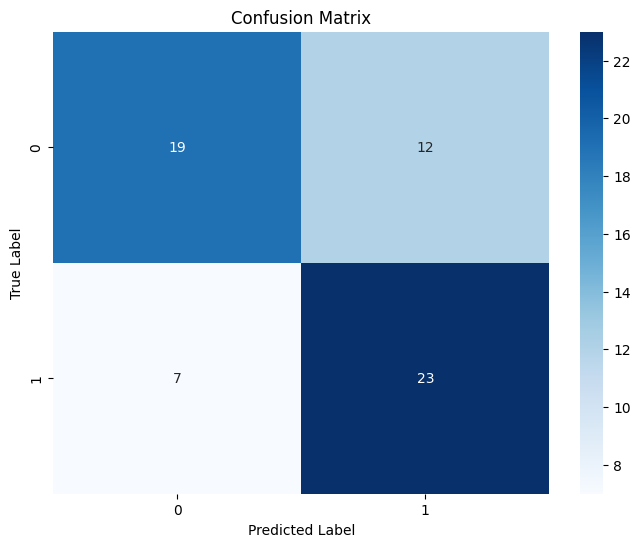

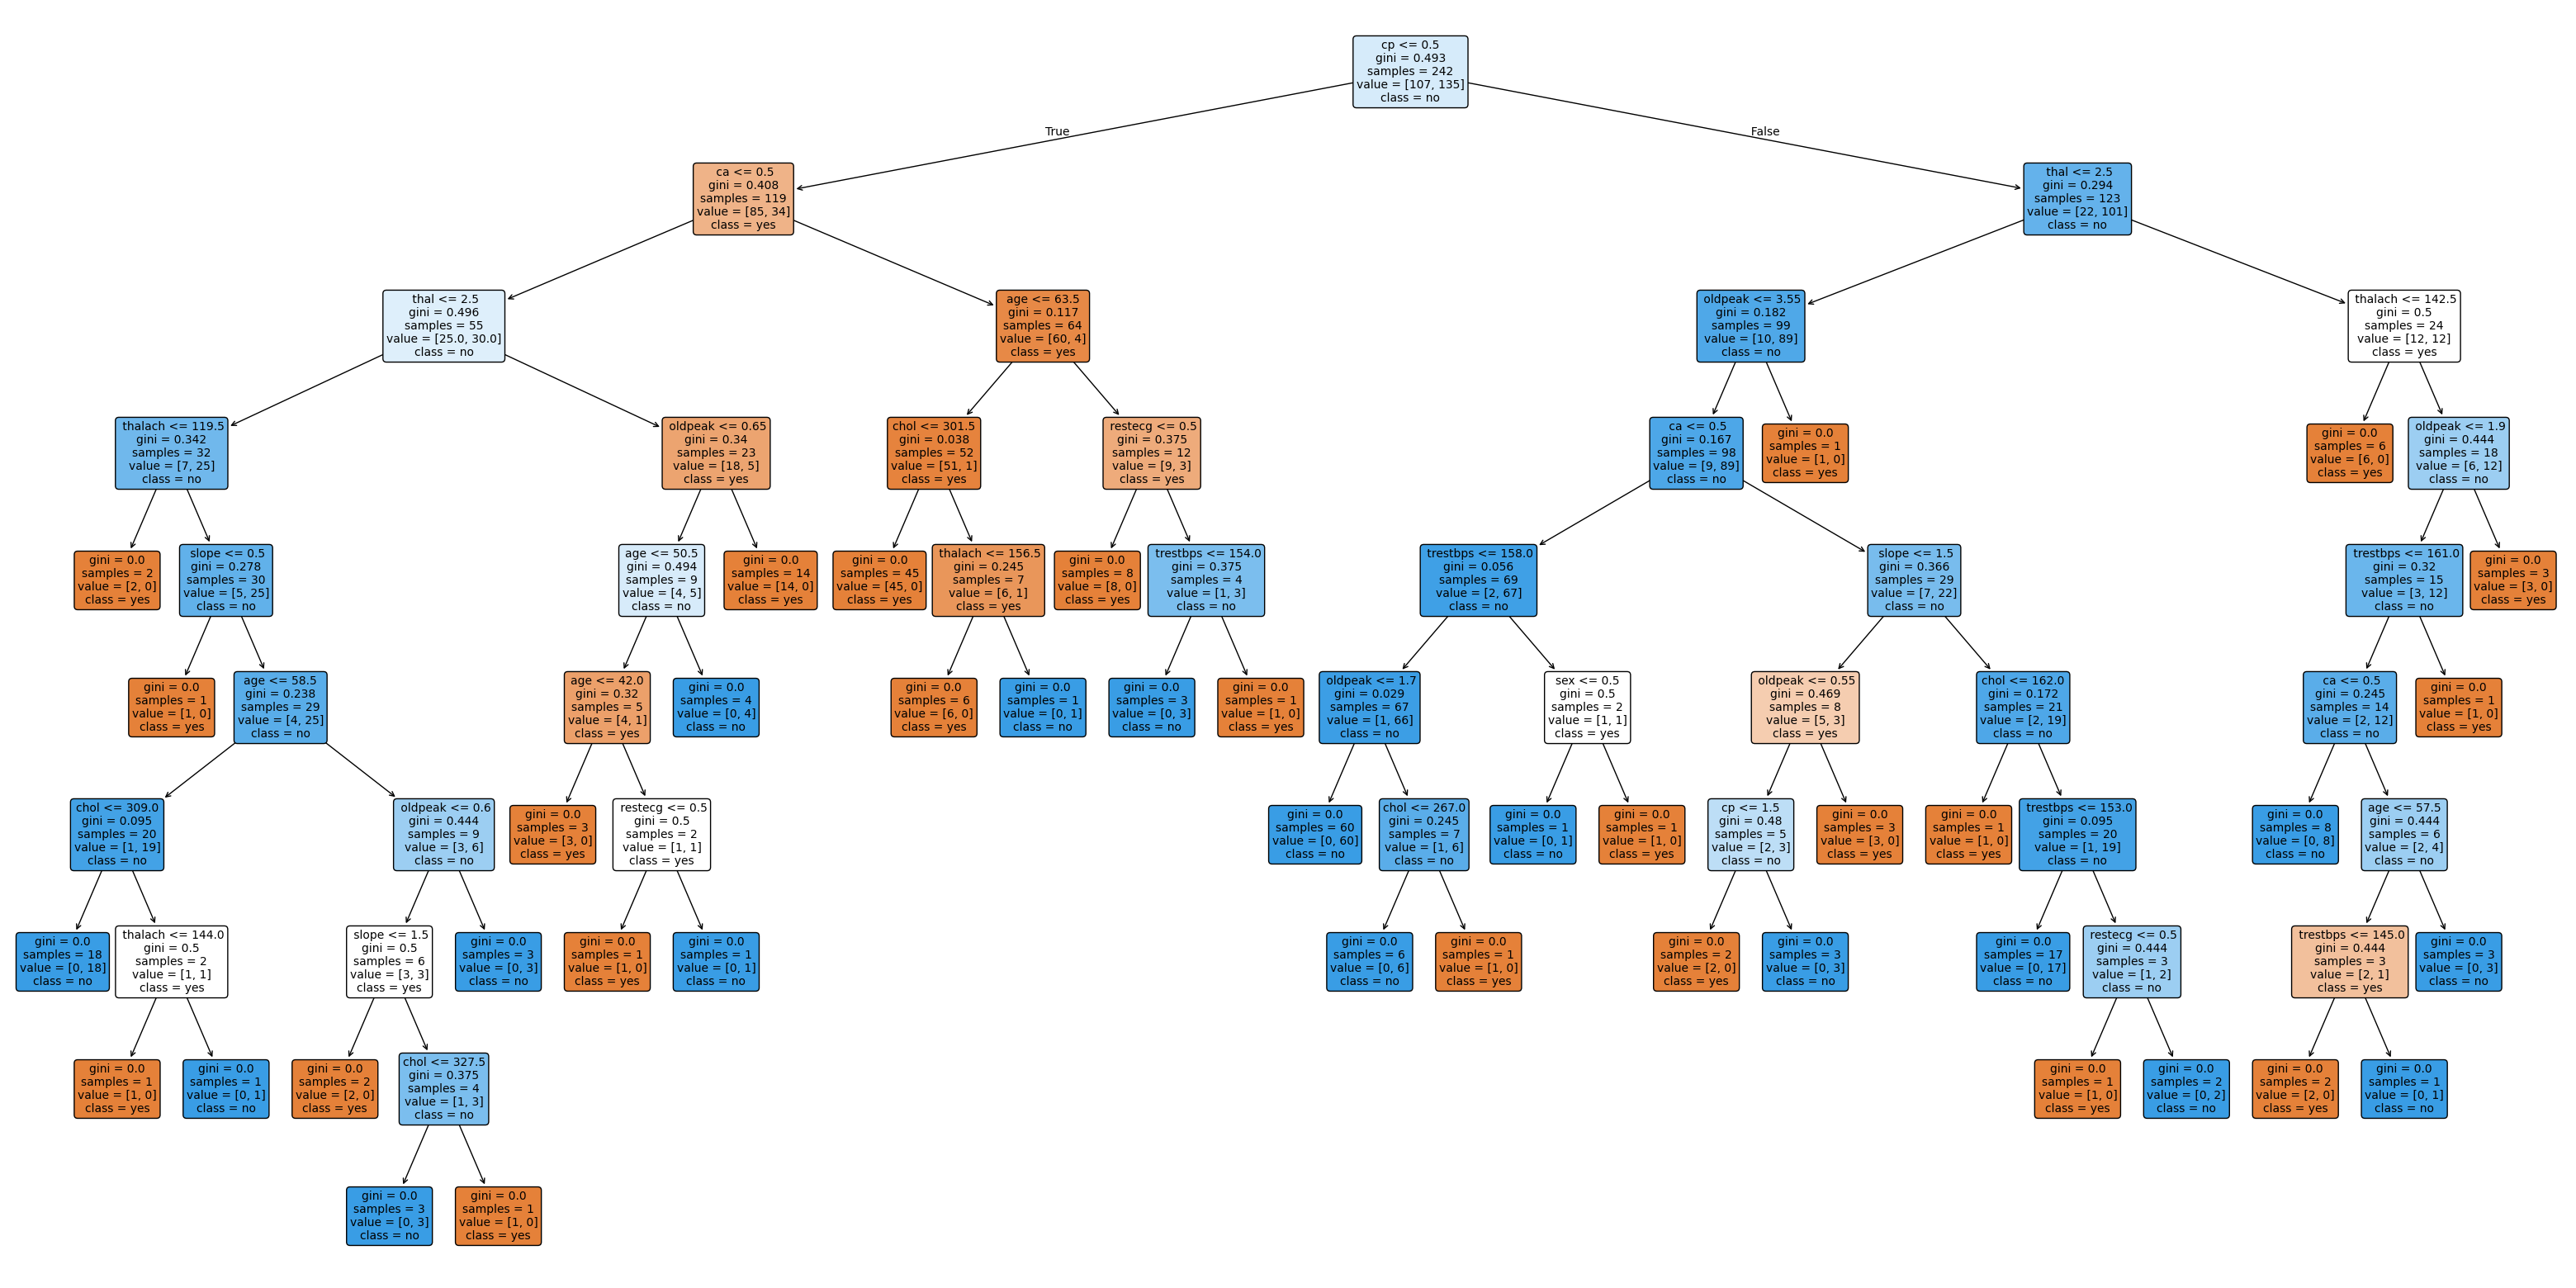

In [10]:
from sklearn . metrics import confusion_matrix
import seaborn as sns

from sklearn. tree import plot_tree

y_pred = gini_model.predict(X_test)
cm = confusion_matrix ( y_test, y_pred)
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize =(8,6))
sns.heatmap(cm,annot = True, fmt='d', cmap ='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


plt.figure(figsize =(40,20))
plot_tree(gini_model, filled=True, feature_names=Data.columns[0:-1], class_names=['yes','no'], rounded=True, fontsize=10)
plt.show()


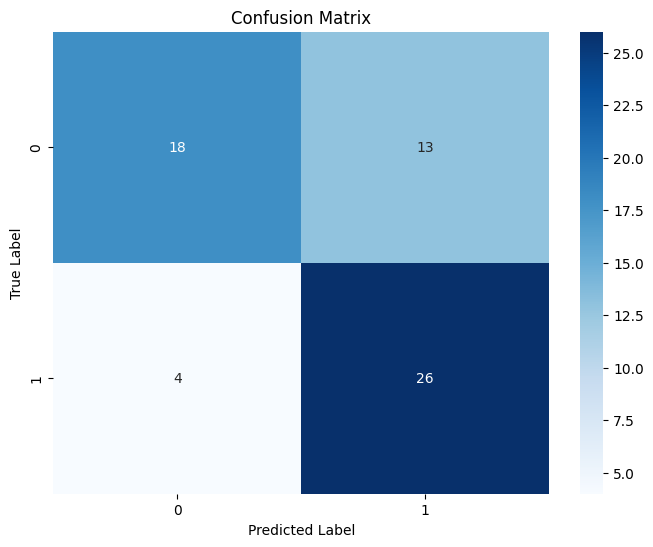

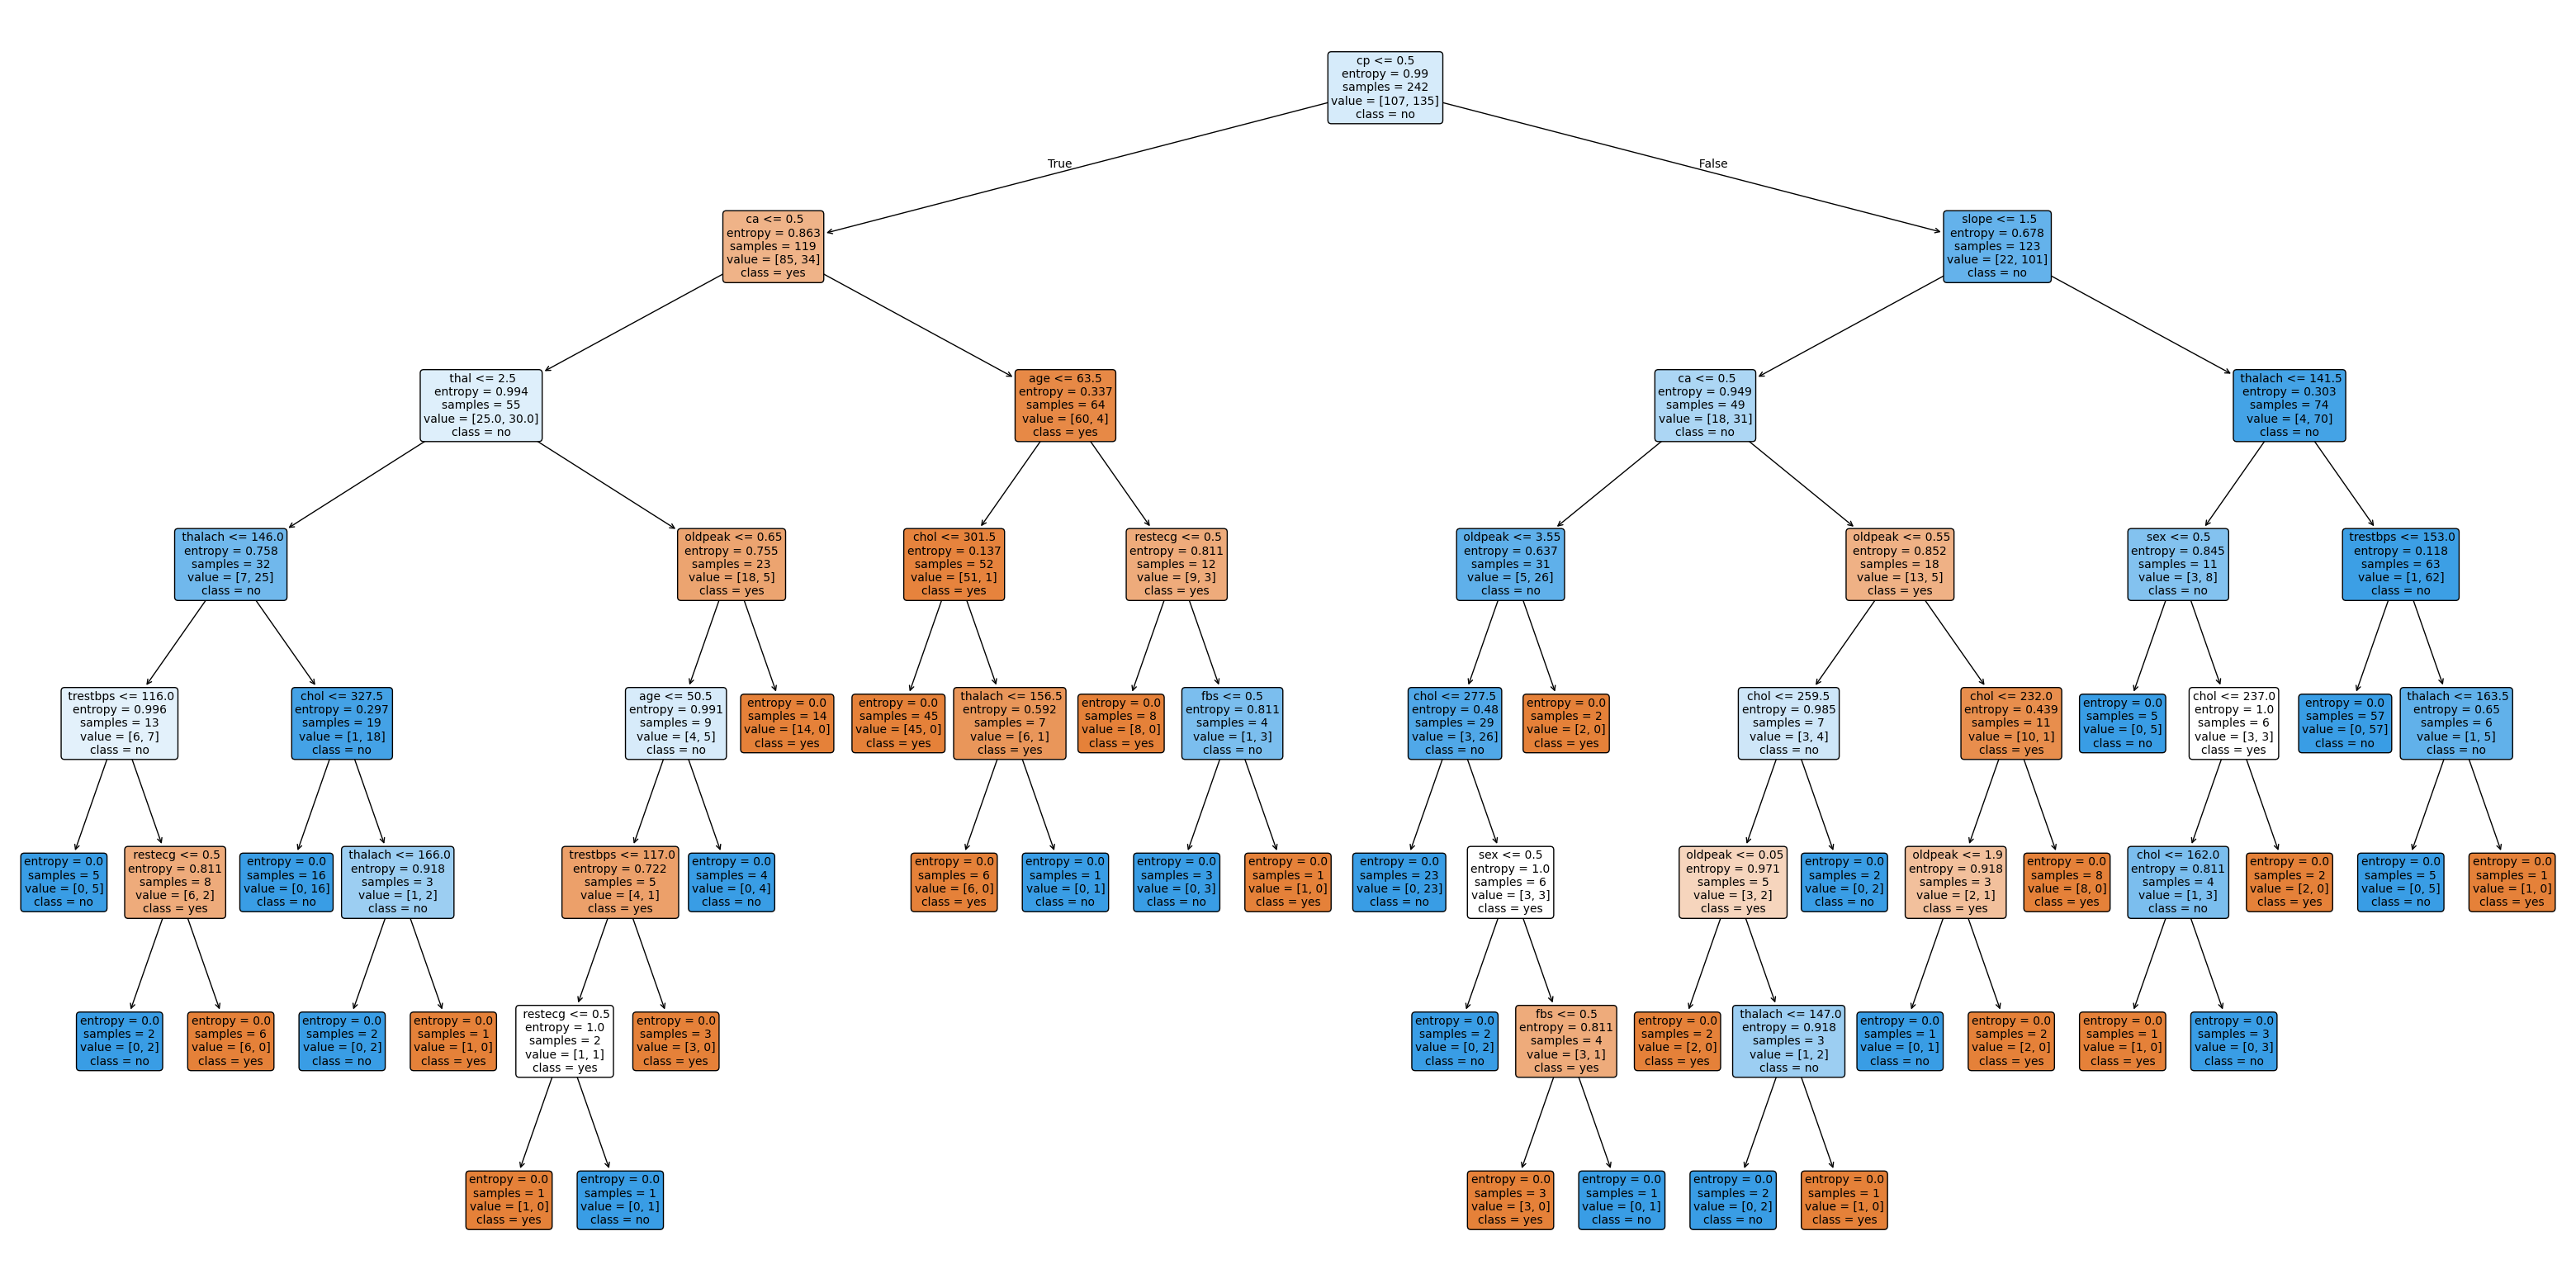

In [11]:
y_pred = info_gain_model.predict(X_test)
cm = confusion_matrix ( y_test, y_pred)
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize =(8,6))
sns.heatmap(cm,annot = True, fmt='d', cmap ='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

plt.figure(figsize =(40,20))
plot_tree(info_gain_model, filled=True, feature_names=Data.columns[0:-1], class_names=['yes','no'], rounded=True, fontsize=10)
plt.show()
